# Entrega Final

# 1. Base de datos

La base de datos se puede obtener en el siguiente enlace: 

https://archive.ics.uci.edu/dataset/256/daily+and+sports+activities

El artículo del paper se puede obtener en el siguiente enlace: 

https://yoksis.bilkent.edu.tr/pdf/files/10.1016-j.patcog.2010.04.019.pdf

The 19 activities are: 

- sitting (A1), 
- standing (A2), 
- lying on back and on right side (A3 and A4), 
- ascending and descending stairs (A5 and A6), 
- standing in an elevator still (A7) 
- and moving around in an elevator (A8), 
- walking in a parking lot (A9), 
- walking on a treadmill with a speed of 4 km/h (in flat and 15 deg inclined positions) (A10 and A11),
- running on a treadmill with a speed of 8 km/h (A12), 
- exercising on a stepper (A13), 
- exercising on a cross trainer (A14), 
- cycling on an exercise bike in horizontal and vertical positions (A15 and A16),
- rowing (A17), 
- jumping (A18), 
- and playing basketball (A19).

# 2. Método

## 2.1. Cargar los datos

In [8]:
import pandas as pd
pd.set_option("display.float_format", "{:.3f}".format)

import os

from abc import ABC, abstractmethod

class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass


class DataLoaderDSA(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for activity in os.listdir(self.src_path):
            act_path = f"{self.src_path}/{activity}"
            for person in os.listdir(act_path):
                person_path = f"{self.src_path}/{activity}/{person}"
                for segment in os.listdir(person_path):
                    segment_path = f"{self.src_path}/{activity}/{person}/{segment}"
                    if self._is_valid_extension(segment):  
                        segment_features = pd.read_csv(segment_path, delimiter=self.delimiter, names=self.keys)
                        segment_features['activity_label'] = activity
                        segment_features['person_id'] = person
                        segment_features['segment'] = f"{activity}{person}{segment}"
                        dataframes.append(segment_features)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df
    
                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)


dsa_path = "dataset/dsaa/data"

keys = [
    # Tronco (T)
    "T_xacc", "T_yacc", "T_zacc", "T_xgyro", "T_ygyro", "T_zgyro", "T_xmag", "T_ymag", "T_zmag",
    
    # Brazo derecho (RA)
    "RA_xacc", "RA_yacc", "RA_zacc", "RA_xgyro", "RA_ygyro", "RA_zgyro", "RA_xmag", "RA_ymag", "RA_zmag",
    
    # Brazo izquierdo (LA)
    "LA_xacc", "LA_yacc", "LA_zacc", "LA_xgyro", "LA_ygyro", "LA_zgyro", "LA_xmag", "LA_ymag", "LA_zmag",
    
    # Pierna derecha (RL)
    "RL_xacc", "RL_yacc", "RL_zacc", "RL_xgyro", "RL_ygyro", "RL_zgyro", "RL_xmag", "RL_ymag", "RL_zmag",
    
    # Pierna izquierda (LL)
    "LL_xacc", "LL_yacc", "LL_zacc", "LL_xgyro", "LL_ygyro", "LL_zgyro", "LL_xmag", "LL_ymag", "LL_zmag"
]

file_extension = '.txt'
delimiter = r','
data_loader = DataLoaderDSA(dsa_path, keys, file_extension, delimiter)

dsa_df = data_loader.load_data()

In [9]:
dsa_df.head()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,...,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,activity_label,person_id,segment
0,8.130,1.035,5.422,-0.009,0.002,-0.003,-0.787,-0.070,0.157,0.701,...,2.622,-0.000,-0.012,-0.004,0.740,0.301,-0.058,a01,p1,a01p1s01.txt
1,8.130,1.020,5.384,-0.009,0.023,0.002,-0.787,-0.068,0.159,0.718,...,2.622,-0.015,-0.016,0.003,0.739,0.302,-0.058,a01,p1,a01p1s01.txt
2,8.160,1.020,5.362,0.015,0.014,0.000,-0.787,-0.068,0.159,0.698,...,2.637,-0.013,0.006,-0.008,0.740,0.301,-0.057,a01,p1,a01p1s01.txt
3,8.160,1.005,5.377,0.007,0.018,0.006,-0.785,-0.070,0.159,0.728,...,2.607,-0.006,0.010,0.007,0.740,0.302,-0.058,a01,p1,a01p1s01.txt
4,8.161,1.028,5.347,0.009,0.030,-0.005,-0.787,-0.069,0.159,0.716,...,2.622,-0.004,-0.008,0.003,0.738,0.301,-0.058,a01,p1,a01p1s01.txt


## 2.2. Pre-proceso

In [11]:
non_sensor_columns = ["activity_label", "person_id", "segment"]
only_sensor_columns = dsa_df.drop(non_sensor_columns, axis="columns")

In [12]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d

# First apply median filter
only_sensor_columns_filtered = only_sensor_columns.apply(lambda col: medfilt(col, kernel_size=3))


# Combine non-sensor and filtered sensor data
dsaa_no_outlier = pd.concat([dsa_df[non_sensor_columns], only_sensor_columns_filtered], axis=1)

dsaa_no_outlier

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-0.034,-2.807,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-0.036,-2.807,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,-0.068,-10.752,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,-0.063,-5.184,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,-0.063,-3.648,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,-0.195,-1.035,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489


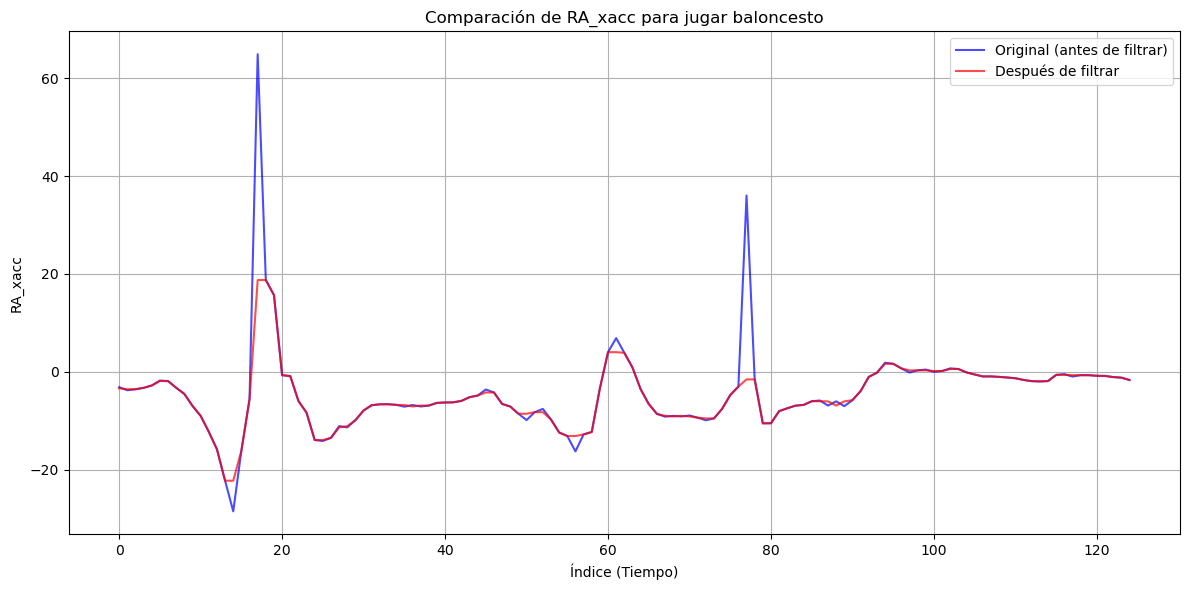

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Define la columna que deseas graficar
columna = 'RA_xacc'  # Cambia este valor para usar otra columna

# Ejemplo: selecciona solo el segmento y persona especificados
segmento_elegido = 'a19p1s03.txt'
persona_elegida = 'p1'

# Filtrar el DataFrame original (dsa_df) y el filtrado (dsaa_no_outlier)
df_original = dsa_df[(dsa_df['segment'] == segmento_elegido) & (dsa_df['person_id'] == persona_elegida)]
df_filtrado = dsaa_no_outlier[(dsaa_no_outlier['segment'] == segmento_elegido) & (dsaa_no_outlier['person_id'] == persona_elegida)]

# Reiniciar índice para asegurar la consistencia al graficar
df_original = df_original.reset_index(drop=True)
df_filtrado = df_filtrado.reset_index(drop=True)

# Ajustar la longitud de ambos DataFrame al mínimo común
min_len = min(len(df_original), len(df_filtrado))
df_original = df_original.iloc[:min_len]
df_filtrado = df_filtrado.iloc[:min_len]

# Graficar la columna elegida de ambos DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df_original[columna], label='Original (antes de filtrar)', color='blue', alpha=0.7)
plt.plot(df_filtrado[columna], label='Después de filtrar', color='red', alpha=0.7)
plt.title(f'Comparación de {columna} para jugar baloncesto')
plt.xlabel('Índice (Tiempo)')
plt.ylabel(columna)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2.3. Segmentación

In [15]:
def segmentar_por_3s(df, window_size=75):
    df_segmentado_list = []
    
    # Agrupamos por actividad y persona
    for (actividad, persona), grupo in df.groupby(['activity_label', 'person_id']):
        # Calculamos cuántas ventanas completas se pueden formar en este grupo
        n_segmentos = len(grupo) // window_size
        
        # Si no hay suficientes filas para una ventana completa, se omite este grupo
        if n_segmentos == 0:
            continue
        
        # Seleccionamos solo las filas que completan ventanas completas
        grupo_completo = grupo.iloc[:n_segmentos * window_size].copy()
        grupo_completo.reset_index(drop=True, inplace=True)
        
        # Creamos un índice de segmento para cada ventana
        grupo_completo['segment_index'] = grupo_completo.index // window_size
        
        # Generamos el identificador único concatenando actividad, persona y el índice del segmento
        grupo_completo['segment_3s'] = grupo_completo.apply(
            lambda row: f"{actividad}{persona}{int(row['segment_index'])}", axis=1
        )
        
        df_segmentado_list.append(grupo_completo)
    
    # Concatenamos todos los grupos procesados en un único DataFrame
    return pd.concat(df_segmentado_list, ignore_index=True)

df_unsegmented = dsaa_no_outlier

dsaa_no_outlier3 = segmentar_por_3s(df_unsegmented)
dsaa_no_outlier3

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,segment_index,segment_3s
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058,0,a01p10
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058,0,a01p10
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058,0,a01p10
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058,0,a01p10
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058,0,a01p10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518,99,a19p899
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504,99,a19p899
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489,99,a19p899
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489,99,a19p899


In [16]:
dsaa_no_outlier3.columns

Index(['activity_label', 'person_id', 'segment', 'T_xacc', 'T_yacc', 'T_zacc',
       'T_xgyro', 'T_ygyro', 'T_zgyro', 'T_xmag', 'T_ymag', 'T_zmag',
       'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro',
       'RA_xmag', 'RA_ymag', 'RA_zmag', 'LA_xacc', 'LA_yacc', 'LA_zacc',
       'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
       'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro',
       'RL_xmag', 'RL_ymag', 'RL_zmag', 'LL_xacc', 'LL_yacc', 'LL_zacc',
       'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag',
       'segment_index', 'segment_3s'],
      dtype='object')

In [17]:
dsaa_no_outlier3.dtypes

activity_label     object
person_id          object
segment            object
T_xacc            float64
T_yacc            float64
T_zacc            float64
T_xgyro           float64
T_ygyro           float64
T_zgyro           float64
T_xmag            float64
T_ymag            float64
T_zmag            float64
RA_xacc           float64
RA_yacc           float64
RA_zacc           float64
RA_xgyro          float64
RA_ygyro          float64
RA_zgyro          float64
RA_xmag           float64
RA_ymag           float64
RA_zmag           float64
LA_xacc           float64
LA_yacc           float64
LA_zacc           float64
LA_xgyro          float64
LA_ygyro          float64
LA_zgyro          float64
LA_xmag           float64
LA_ymag           float64
LA_zmag           float64
RL_xacc           float64
RL_yacc           float64
RL_zacc           float64
RL_xgyro          float64
RL_ygyro          float64
RL_zgyro          float64
RL_xmag           float64
RL_ymag           float64
RL_zmag     

In [18]:
dsaa_no_outlier3.groupby(['activity_label', 'person_id'])['segment_3s'].nunique()

activity_label  person_id
a01             p1           100
                p2           100
                p3           100
                p4           100
                p5           100
                            ... 
a19             p4           100
                p5           100
                p6           100
                p7           100
                p8           100
Name: segment_3s, Length: 152, dtype: int64

## 2.4. Extracción de características

In [20]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

In [21]:
import numpy as np
import pandas as pd

# Assume dsaa_no_outlier3 has a column 'person_id'
df_to_extract_features = dsaa_no_outlier3

numeric_features_list = []
labels = []
person_ids = []  # new list to collect person IDs

for seg, group in df_to_extract_features.groupby("segment_3s"):
    # Extract person ID (assuming column named 'person_id')
    pid = group["person_id"].iloc[0]

    # Torso
    T_features = InertialSensor(group.T_xacc, group.T_yacc, group.T_zacc).extract_features()
    T_gyro_features = InertialSensor(group.T_xgyro, group.T_ygyro, group.T_zgyro).extract_features()
    T_mag_features = InertialSensor(group.T_xmag, group.T_ymag, group.T_zmag).extract_features()

    # Right Arm
    RA_features = InertialSensor(group.RA_xacc, group.RA_yacc, group.RA_zacc).extract_features()
    RA_gyro_features = InertialSensor(group.RA_xgyro, group.RA_ygyro, group.RA_zgyro).extract_features()
    RA_mag_features = InertialSensor(group.RA_xmag, group.RA_ymag, group.RA_zmag).extract_features()

    # Left Arm
    LA_features = InertialSensor(group.LA_xacc, group.LA_yacc, group.LA_zacc).extract_features()
    LA_gyro_features = InertialSensor(group.LA_xgyro, group.LA_ygyro, group.LA_zgyro).extract_features()
    LA_mag_features = InertialSensor(group.LA_xmag, group.LA_ymag, group.LA_zmag).extract_features()

    # Right Leg
    RL_features = InertialSensor(group.RL_xacc, group.RL_yacc, group.RL_zacc).extract_features()
    RL_gyro_features = InertialSensor(group.RL_xgyro, group.RL_ygyro, group.RL_zgyro).extract_features()
    RL_mag_features = InertialSensor(group.RL_xmag, group.RL_ymag, group.RL_zmag).extract_features()

    # Left Leg
    LL_features = InertialSensor(group.LL_xacc, group.LL_yacc, group.LL_zacc).extract_features()
    LL_gyro_features = InertialSensor(group.LL_xgyro, group.LL_ygyro, group.LL_zgyro).extract_features()
    LL_mag_features = InertialSensor(group.LL_xmag, group.LL_ymag, group.LL_zmag).extract_features()
    
    # Combine all feature sets into one row and convert numeric values to float
    feature_vector = np.concatenate([
        T_features, T_gyro_features, T_mag_features,
        RA_features, RA_gyro_features, RA_mag_features,
        LA_features, LA_gyro_features, LA_mag_features,
        RL_features, RL_gyro_features, RL_mag_features,
        LL_features, LL_gyro_features, LL_mag_features
    ]).astype(float)
    
    numeric_features_list.append(feature_vector)
    labels.append(group["activity_label"].iloc[0])
    person_ids.append(pid)  # add the person ID to the list

# Generate feature column names
sensor_locations = ["T", "RA", "LA", "RL", "LL"]
sensor_types = ["acc", "gyro", "mag"]
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

feature_columns = [
    f"{loc}_{typ}_{feat}"
    for loc in sensor_locations
    for typ in sensor_types
    for feat in feature_names
]

# Create DataFrame for numeric features and convert to float
df_numeric = pd.DataFrame(np.array(numeric_features_list), columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Create DataFrame for person IDs
df_person_id = pd.DataFrame(person_ids, columns=["person_id"])

# Concatenate numeric features, labels, and person IDs
examples = pd.concat([df_numeric, df_labels, df_person_id], axis=1)

# Optionally, check the first few rows and data types
display(examples.head())
display(examples.dtypes)

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1


T_acc_mean_x        float64
T_acc_mean_y        float64
T_acc_mean_z        float64
T_acc_std_x         float64
T_acc_std_y         float64
                     ...   
LL_mag_std_mag      float64
LL_mag_auc          float64
LL_mag_mean_diff    float64
activity             object
person_id            object
Length: 242, dtype: object

In [22]:
examples

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,-0.027,0.511,-0.086,-0.450,0.861,0.047,64.589,0.001,a19,p8
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,0.667,-0.264,-0.735,-0.106,0.930,0.016,69.735,0.000,a19,p8
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,0.675,-0.362,-0.941,0.523,0.932,0.013,69.889,0.000,a19,p8
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,0.626,-0.206,-0.812,-0.356,0.912,0.008,68.395,-0.000,a19,p8


In [23]:
import pandas as pd

# Supongamos que tu DataFrame se llama `examples`
conteos_por_clase = examples['activity'].value_counts()

df_conteos = conteos_por_clase.rename_axis('activity').reset_index(name='count')
df_conteos

,activity,count
0,a01,800
1,a11,800
2,a18,800
3,a17,800
4,a16,800
5,a15,800
6,a14,800
7,a13,800
8,a12,800
9,a10,800


## 2.5. Entrenamiento

In [25]:
pd.set_option('display.float_format', '{:.5f}'.format)

### 2.5.1. 10-Fold Cross Validation

#### 2.5.1.1. Pipelinear Cross Validation

In [86]:
import os
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Para que el texto sea seleccionable en SVG
matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_crossvalidation(model, X, y):
    """
    Ajusta un pipeline (escalador + modelo) con CV estratificada de 10 pliegues.
    Muestra estadísticas de F1-macro, accuracy, precision-macro y recall-macro
    (con zero_division=0), imprime todo en español, y dibuja/exporta la
    matriz de confusión out-of-fold en PNG (1080p, 4K) y SVG.
    El archivo se guarda en resultados_dsaa/crossval_10k/
    con nombre "Validación Cruzada 10P {NombreDelClasificador}".
    """
    # 0) Codificación de etiquetas si vienen como texto
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_encoded = y
        etiquetas = np.unique(y)

    # 1) Scorers
    precision_macro_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_macro_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_macro_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy_scorer    = 'accuracy'

    # 2) Pipeline + CV
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_encoded,
        cv=cv,
        scoring={
            "f1_macro":        f1_macro_zd,
            "accuracy":        accuracy_scorer,
            "precision_macro": precision_macro_zd,
            "recall_macro":    recall_macro_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 3) Extraer métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(cv.get_n_splits())
    ]

    # 4) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 5) Impresión de métricas (solo 5 decimales)
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        linea = "  ".join(f"{s:.5f}" for s in scores[i:i+5])
        print(f"  {linea}")
    print("\nEstadísticas de F1-macro:")
    for etiqueta, valor in stats_scores.items():
        print(f"{etiqueta + ':':<12} {valor:.5f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        linea = "  ".join(f"{t:.5f}" for t in times[i:i+5])
        print(f"  {linea}")
    print("\nEstadísticas de tiempos:")
    for etiqueta, valor in stats_times.items():
        print(f"{etiqueta + ':':<12} {valor:.5f}")

    # 6) Predicciones out-of-fold y matriz de confusión
    y_pred = cross_val_predict(pipe, X, y_encoded, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_encoded, y_pred)

    # 7) Carpeta de salida
    output_folder = os.path.join("resultados_dsaa", "crossval_10k")
    os.makedirs(output_folder, exist_ok=True)

    # 8) Dibujar matriz de confusión en español
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=etiquetas, yticklabels=etiquetas, ax=ax
    )
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada 10P {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    # 9) Guardar en varios formatos
    base_name = f"Validación Cruzada 10-Folds {model.__class__.__name__}"
    fig.savefig(
        os.path.join(output_folder, f"{base_name}_1080p.png"),
        dpi=192, bbox_inches='tight'
    )
    fig.savefig(
        os.path.join(output_folder, f"{base_name}_4k.png"),
        dpi=384, bbox_inches='tight'
    )
    fig.savefig(
        os.path.join(output_folder, f"{base_name}.svg"),
        bbox_inches='tight'
    )

    return scores, times, all_scores

#### 2.5.1.2. Entrenar

1 Naive Bayes:

Puntuaciones (F1-macro):
  0.95773  0.96798  0.96765  0.95853  0.95068
  0.95977  0.96413  0.95295  0.95931  0.96069

Estadísticas de F1-macro:
Media:       0.95994
Mediana:     0.95954
Desvío:      0.00533
Mínimo:      0.95068
Máximo:      0.96798

Tiempos de entrenamiento (s):
  0.46104  0.53404  0.51704  0.52304  0.43504
  0.53904  0.57004  0.42503  0.39704  0.33902

Estadísticas de tiempos:
Media:       0.47404
Mediana:     0.48904
Desvío:      0.07039
Mínimo:      0.33902
Máximo:      0.57004


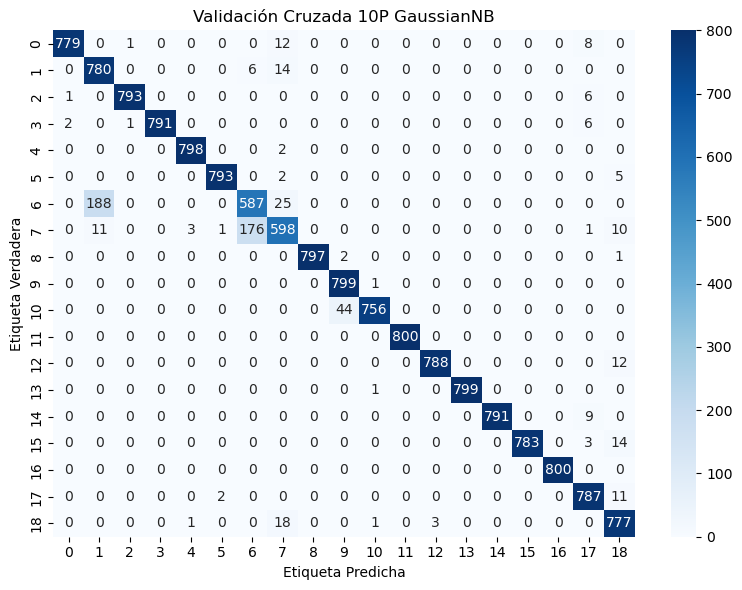

In [88]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipelinear_crossvalidation(nb, X, y_encoded)

2 Logistic Regression

Puntuaciones (F1-macro):
  0.99399  0.99338  0.99408  0.99407  0.99278
  0.99143  0.99342  0.99214  0.99473  0.99604

Estadísticas de F1-macro:
Media:       0.99361
Mediana:     0.99370
Desvío:      0.00124
Mínimo:      0.99143
Máximo:      0.99604

Tiempos de entrenamiento (s):
  10.62181  10.98483  9.51572  10.95883  11.69889
  10.51781  10.07677  11.11184  4.75636  4.35124

Estadísticas de tiempos:
Media:       9.45941
Mediana:     10.56981
Desvío:      2.51771
Mínimo:      4.35124
Máximo:      11.69889


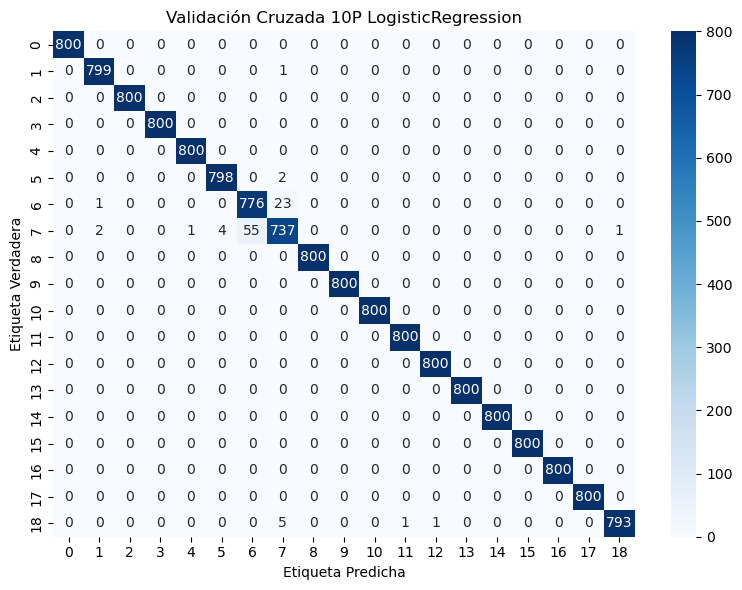

In [91]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results = pipelinear_crossvalidation(lr, X, y_encoded)

3 MLP

Puntuaciones (F1-macro):
  0.98830  0.99339  0.99083  0.98817  0.99340
  0.98818  0.98753  0.99015  0.99147  0.99338

Estadísticas de F1-macro:
Media:       0.99048
Mediana:     0.99049
Desvío:      0.00225
Mínimo:      0.98753
Máximo:      0.99340

Tiempos de entrenamiento (s):
  4.03331  3.98430  4.44334  4.53434  4.62135
  3.98230  3.64127  4.30633  2.39917  2.19316

Estadísticas de tiempos:
Media:       3.81389
Mediana:     4.00881
Desvío:      0.81076
Mínimo:      2.19316
Máximo:      4.62135


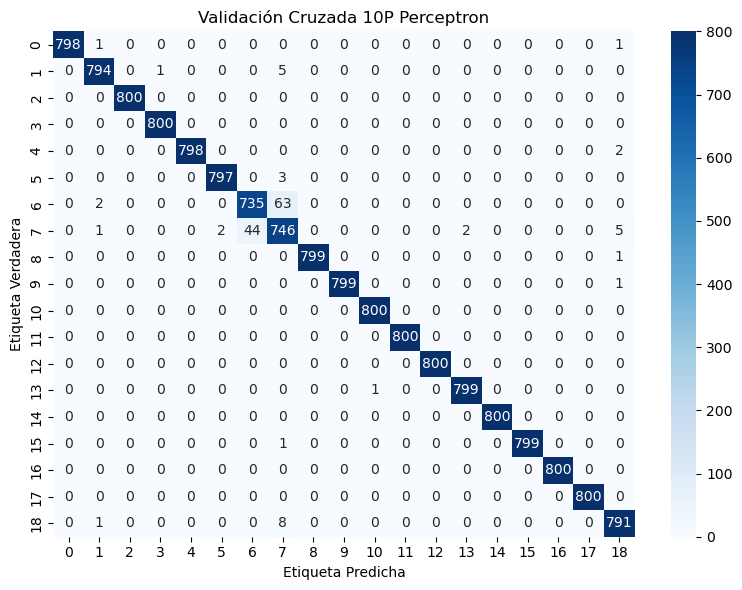

In [94]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results = pipelinear_crossvalidation(perceptron, X, y_encoded)

4 Random Forest:

Puntuaciones (F1-macro):
  0.99468  0.99671  0.99540  0.99737  0.99212
  0.99737  0.99868  0.99471  0.99348  0.99803

Estadísticas de F1-macro:
Media:       0.99585
Mediana:     0.99605
Desvío:      0.00201
Mínimo:      0.99212
Máximo:      0.99868

Tiempos de entrenamiento (s):
  31.49739  31.02135  29.45723  29.68625  31.77141
  29.87226  31.41638  31.48239  22.24269  22.22169

Estadísticas de tiempos:
Media:       29.06690
Mediana:     30.44681
Desvío:      3.50724
Mínimo:      22.22169
Máximo:      31.77141


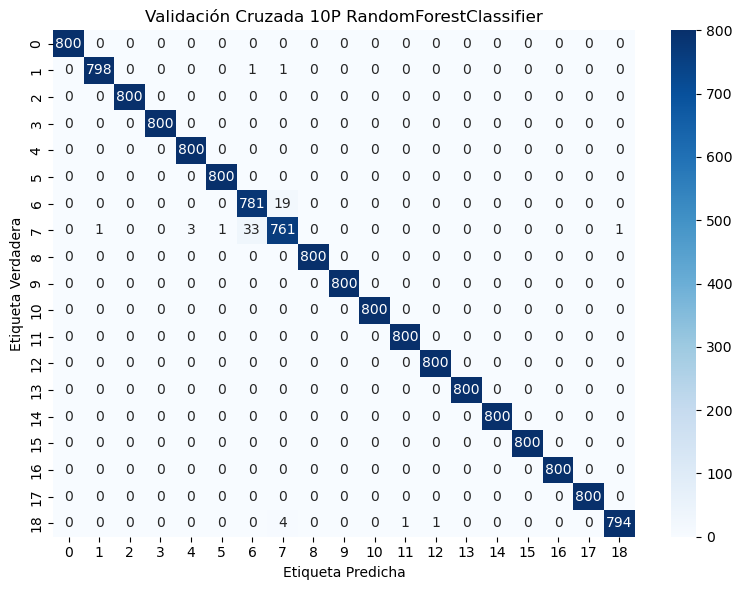

In [95]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

5 AdaBoost:

Puntuaciones (F1-macro):
  0.98542  0.98944  0.98764  0.99145  0.98301
  0.98684  0.98477  0.98368  0.99017  0.99210

Estadísticas de F1-macro:
Media:       0.98745
Mediana:     0.98724
Desvío:      0.00307
Mínimo:      0.98301
Máximo:      0.99210

Tiempos de entrenamiento (s):
  370.73209  375.39064  372.09353  381.41560  361.89876
  383.25762  367.04046  382.63728  262.52672  261.48574

Estadísticas de tiempos:
Media:       351.84784
Mediana:     371.41281
Desvío:      45.39272
Mínimo:      261.48574
Máximo:      383.25762


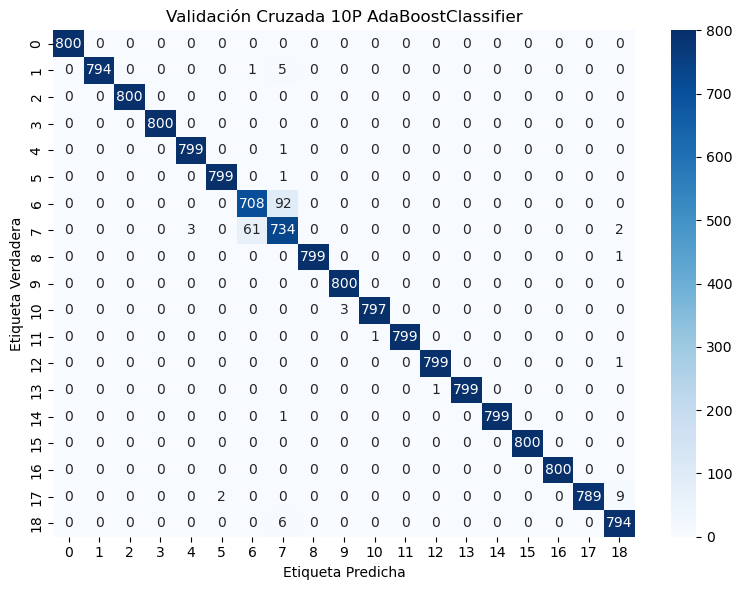

In [189]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada  = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

ada_results = pipelinear_crossvalidation(ada, X, y_encoded)

**6 EL OTRO MÉTODO**

In [192]:
"""
 - Estandariza, selecciona características (SFS k=3) y ensambla (soft voting).
 - Evalúa con StratifiedKFold(10) y métricas macro: f1, accuracy, precision, recall.
"""

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 2) SequentialFeatureSelector (k=3, scoring interno f1_macro, cv=5) 
sfs1 = SequentialFeatureSelector(clf1, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs2 = SequentialFeatureSelector(clf2, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs3 = SequentialFeatureSelector(clf3, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('sfs', sfs1),
                    ('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('sfs', sfs2), ('rf', clf2)])
pipe_nb = Pipeline([('sfs', sfs3), ('nb', clf3)])

# 4) Ensamble de votación suave
eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

# 5) Función de evaluación renombrada
def evaluar_sfs_ensemble(model, X, y):
    """
    Estandariza, entrena el modelo y evalúa con CV estratificada.
    Métricas: f1_macro, accuracy, precision_macro, recall_macro + tiempos de entrenamiento
    """
    # Pipeline con scaler + model
    pipe = make_pipeline(StandardScaler(), model)

    # Diccionario de scorers macro 
    scoring = {
        'f1_macro':       make_scorer(f1_score,       average='macro'),
        'accuracy':       make_scorer(accuracy_score),
        'precision_macro':make_scorer(precision_score,average='macro'),
        'recall_macro':   make_scorer(recall_score,   average='macro'),
    }

    # CV externo: StratifiedKFold 10 folds, shuffle, semilla fija 
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # cross_validate con múltiples métricas y paralelo :contentReference[oaicite:6]{index=6}
    cv_results = cross_validate(estimator=pipe, X=X, y=y,
                                cv=cv, scoring=scoring,
                                return_train_score=False, n_jobs=-1)

    # Estadísticas resumen
    def stats_arr(arr):
        return {
            "Media":   np.mean(arr),
            "Mediana": np.median(arr),
            "Std":     np.std(arr),
            "Mínimo":  np.min(arr),
            "Máximo":  np.max(arr),
        }

    # Mostrar métricas por fold
    print("=== Métricas de test por fold ===")
    for metric in scoring:
        vals = cv_results[f'test_{metric}']
        stats = stats_arr(vals)
        print(f"\n> {metric}:")
        print("  " + "  ".join(f"{v:.4f}" for v in vals))
        for name, v in stats.items():
            print(f"    {name:<8}{v:.4f}")

    # Mostrar tiempos de entrenamiento
    times = cv_results["fit_time"]
    stats_t = stats_arr(times)
    print("\n=== Tiempos de entrenamiento (s) ===")
    print("  " + "  ".join(f"{t:.4f}" for t in times))
    for name, v in stats_t.items():
        print(f"    {name:<8}{v:.4f}")

    return cv_results

# 6) Para ejecutar con tus datos:
eclf_results = evaluar_sfs_ensemble(eclf, X, y)
eclf_results

KeyboardInterrupt: 

#### 2.5.1.1. Resultados

In [38]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    for fold in classifier_results[2]:
        metrics = {
            "accuracy":        agg_func(fold["accuracy"]),
            "precision_macro": agg_func(fold["precision_macro"]),
            "recall_macro":    agg_func(fold["recall_macro"]),
            "f1_macro":        agg_func(fold["f1_macro"]),
        }
    return metrics

# Obtenemos los resultados por clasificador
nb_metrics      = compute_metrics(nb_results)
rf_metrics      = compute_metrics(rf_results)
bagged_metrics  = compute_metrics(bagged_results)
xgb_metrics     = compute_metrics(xgb_results)

# Crear un diccionario con los resultados
all_metrics = {
    "Naive Bayes":    nb_metrics,
    "Random Forest":  rf_metrics,
    "Bagged Trees":   bagged_metrics,
    "XGBoost":        xgb_metrics,
}

# Crear el DataFrame
df_metrics = pd.DataFrame.from_dict(all_metrics, orient="index")

# Redondear a cinco decimales
df_metrics = df_metrics.round(5)

print(df_metrics)


               accuracy  precision_macro  recall_macro  f1_macro
Naive Bayes     0.96118          0.96343       0.96118   0.96069
Random Forest   0.99803          0.99803       0.99803   0.99803
Bagged Trees    0.99342          0.99349       0.99342   0.99343
XGBoost         0.99934          0.99935       0.99934   0.99934


### 2.5.2. LOSO

#### 2.5.2.1. Pieplinear: LOSO

In [117]:
import os
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_validate, GroupKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Para que el texto sea seleccionable en SVG
matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_loso(model, X, y, groups, n_splits=8):
    """
    Ajusta un pipeline (escalador + modelo) con CV por grupos (GroupKFold).
    X: features, y: etiquetas, groups: vector de grupos.
    Muestra estadísticas de F1-macro, accuracy, precision-macro y recall-macro
    (con zero_division=0), imprime todo en español, y dibuja/exporta la
    matriz de confusión out-of-fold en PNG (1080p, 4K) y SVG.
    El archivo se guarda en resultados_dsaa/crossval_groups/
    con nombre "Validación Cruzada Grupos {NombreDelClasificador}".
    """
    # 0) Codificación de etiquetas si vienen como texto
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_enc = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_enc = y
        etiquetas = np.unique(y)

    # 1) Scorers
    precision_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy     = 'accuracy'

    # 2) Pipeline + GroupKFold
    pipe = make_pipeline(StandardScaler(), model)
    cv = GroupKFold(n_splits=n_splits)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_enc, groups=groups,
        cv=cv,
        scoring={
            "f1_macro":        f1_zd,
            "accuracy":        accuracy,
            "precision_macro": precision_zd,
            "recall_macro":    recall_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 3) Extraer métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(n_splits)
    ]

    # 4) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 5) Impresión de métricas (5 decimales)
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for k, v in stats_scores.items():
        print(f"{k + ':':<12} {v:.5f}")
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for k, v in stats_times.items():
        print(f"{k + ':':<12} {v:.5f}")

    # 6) Predicciones out-of-fold y matriz de confusión
    y_pred = cross_val_predict(pipe, X, y_enc, groups=groups, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_enc, y_pred)

    # 7) Carpeta de salida
    output_folder = os.path.join("resultados_dsaa", "crossval_groups")
    os.makedirs(output_folder, exist_ok=True)

    # 8) Dibujar matriz de confusión en español
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=etiquetas, yticklabels=etiquetas, ax=ax
    )
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada Grupos {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    # 9) Guardar en varios formatos
    base = f"Validación Cruzada Grupos {model.__class__.__name__}"
    fig.savefig(os.path.join(output_folder, f"{base}_1080p.png"), dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}_4k.png"),   dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}.svg"),              bbox_inches='tight')

    return scores, times, all_scores


#### 2.5.2.2. Entrenar

Gaussian NB

Puntuaciones (F1-macro):
  0.64524  0.89994  0.94893  0.90550  0.75063
  0.86867  0.94647  0.94422

Estadísticas de F1-macro:
Media:       0.86370
Mediana:     0.90272
Desvío:      0.10259
Mínimo:      0.64524
Máximo:      0.94893

Tiempos de entrenamiento (s):
  0.48404  0.53205  0.57905  0.46804  0.58505
  0.48705  0.69206  0.46804

Estadísticas de tiempos:
Media:       0.53692
Mediana:     0.50955
Desvío:      0.07328
Mínimo:      0.46804
Máximo:      0.69206


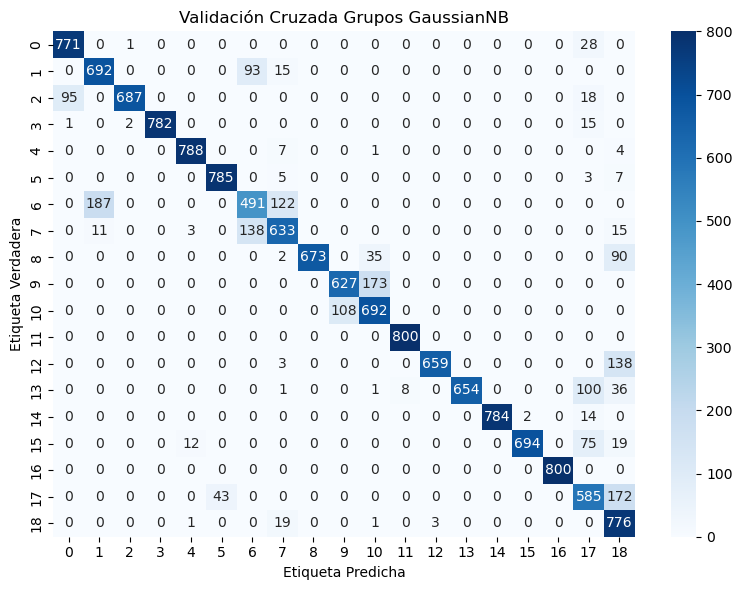

F1-macro por fold: [0.6452422  0.89993682 0.94892968 0.90549698 0.75063098 0.86867084
 0.94647038 0.94421578]
Tiempos de entrenamiento por fold (s): [0.5160408  0.54304695 0.52104807 0.52504396 0.52504396 0.51904511
 0.52805281 0.52604413]
Detalle de métricas por fold: [{'f1_macro': 0.6452421972787458, 'accuracy': 0.708421052631579, 'precision_macro': 0.6610779490316133, 'recall_macro': 0.708421052631579}, {'f1_macro': 0.8999368182480962, 'accuracy': 0.8973684210526316, 'precision_macro': 0.9269890965763292, 'recall_macro': 0.8973684210526316}, {'f1_macro': 0.9489296789370109, 'accuracy': 0.95, 'precision_macro': 0.9573563409535477, 'recall_macro': 0.9500000000000001}, {'f1_macro': 0.9054969805524687, 'accuracy': 0.911578947368421, 'precision_macro': 0.9351447910465768, 'recall_macro': 0.911578947368421}, {'f1_macro': 0.7506309752652356, 'accuracy': 0.8010526315789473, 'precision_macro': 0.7768765745132965, 'recall_macro': 0.8010526315789473}, {'f1_macro': 0.8686708362735324, 'accuracy

In [119]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
model = GaussianNB()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
nb_loso = pipelinear_loso(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)

# 6) Revisar resultados
print("F1-macro por fold:", scores)
print("Tiempos de entrenamiento por fold (s):", times)
print("Detalle de métricas por fold:", all_scores)

2 Logistic Regression

Puntuaciones (F1-macro):
  0.88322  0.95326  0.91127  0.87785  0.90107
  0.97102  0.95173  0.96364

Estadísticas de F1-macro:
Media:       0.92663
Mediana:     0.93150
Desvío:      0.03506
Mínimo:      0.87785
Máximo:      0.97102

Tiempos de entrenamiento (s):
  8.11862  10.31578  10.98583  9.50272  9.71875
  9.92976  9.98776  11.11784

Estadísticas de tiempos:
Media:       9.95963
Mediana:     9.95876
Desvío:      0.87886
Mínimo:      8.11862
Máximo:      11.11784


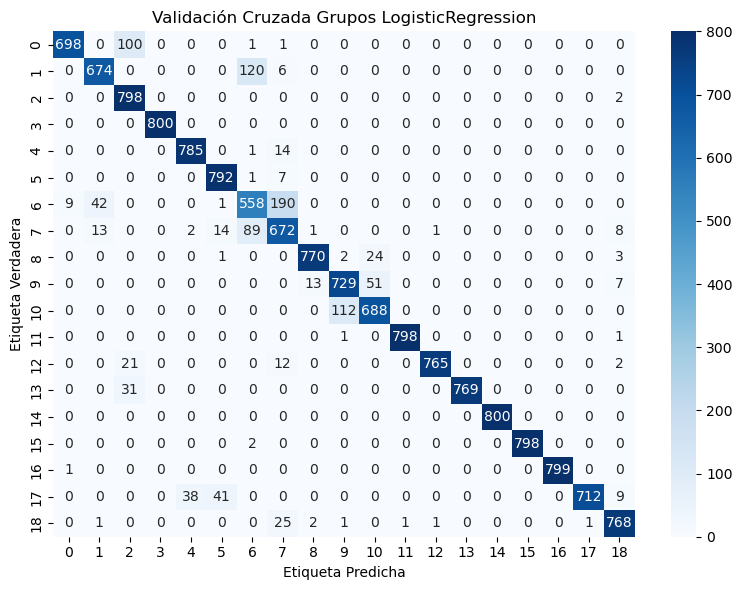

F1-macro por fold: [0.6452422  0.89993682 0.94892968 0.90549698 0.75063098 0.86867084
 0.94647038 0.94421578]
Tiempos de entrenamiento por fold (s): [0.5160408  0.54304695 0.52104807 0.52504396 0.52504396 0.51904511
 0.52805281 0.52604413]
Detalle de métricas por fold: [{'f1_macro': 0.6452421972787458, 'accuracy': 0.708421052631579, 'precision_macro': 0.6610779490316133, 'recall_macro': 0.708421052631579}, {'f1_macro': 0.8999368182480962, 'accuracy': 0.8973684210526316, 'precision_macro': 0.9269890965763292, 'recall_macro': 0.8973684210526316}, {'f1_macro': 0.9489296789370109, 'accuracy': 0.95, 'precision_macro': 0.9573563409535477, 'recall_macro': 0.9500000000000001}, {'f1_macro': 0.9054969805524687, 'accuracy': 0.911578947368421, 'precision_macro': 0.9351447910465768, 'recall_macro': 0.911578947368421}, {'f1_macro': 0.7506309752652356, 'accuracy': 0.8010526315789473, 'precision_macro': 0.7768765745132965, 'recall_macro': 0.8010526315789473}, {'f1_macro': 0.8686708362735324, 'accuracy

In [125]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
lr_loso = pipelinear_loso(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)

# 6) Revisar resultados
print("F1-macro por fold:", scores)
print("Tiempos de entrenamiento por fold (s):", times)
print("Detalle de métricas por fold:", all_scores)

3 MLP

Puntuaciones (F1-macro):
  0.83708  0.91629  0.84605  0.92052  0.82890
  0.91113  0.94136  0.81480

Estadísticas de F1-macro:
Media:       0.87702
Mediana:     0.87859
Desvío:      0.04674
Mínimo:      0.81480
Máximo:      0.94136

Tiempos de entrenamiento (s):
  4.42533  3.84229  4.34833  4.17632  4.34533
  4.41333  4.64835  3.87330

Estadísticas de tiempos:
Media:       4.25907
Mediana:     4.34683
Desvío:      0.26167
Mínimo:      3.84229
Máximo:      4.64835


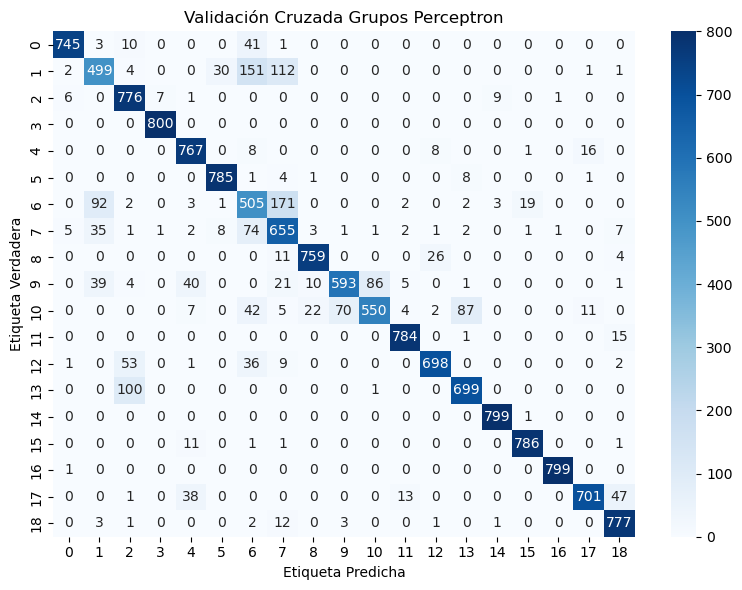

F1-macro por fold: [0.6452422  0.89993682 0.94892968 0.90549698 0.75063098 0.86867084
 0.94647038 0.94421578]
Tiempos de entrenamiento por fold (s): [0.5160408  0.54304695 0.52104807 0.52504396 0.52504396 0.51904511
 0.52805281 0.52604413]
Detalle de métricas por fold: [{'f1_macro': 0.6452421972787458, 'accuracy': 0.708421052631579, 'precision_macro': 0.6610779490316133, 'recall_macro': 0.708421052631579}, {'f1_macro': 0.8999368182480962, 'accuracy': 0.8973684210526316, 'precision_macro': 0.9269890965763292, 'recall_macro': 0.8973684210526316}, {'f1_macro': 0.9489296789370109, 'accuracy': 0.95, 'precision_macro': 0.9573563409535477, 'recall_macro': 0.9500000000000001}, {'f1_macro': 0.9054969805524687, 'accuracy': 0.911578947368421, 'precision_macro': 0.9351447910465768, 'recall_macro': 0.911578947368421}, {'f1_macro': 0.7506309752652356, 'accuracy': 0.8010526315789473, 'precision_macro': 0.7768765745132965, 'recall_macro': 0.8010526315789473}, {'f1_macro': 0.8686708362735324, 'accuracy

In [128]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
from sklearn.linear_model import Perceptron
model = Perceptron()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
mlp_loso = pipelinear_loso(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)

# 6) Revisar resultados
print("F1-macro por fold:", scores)
print("Tiempos de entrenamiento por fold (s):", times)
print("Detalle de métricas por fold:", all_scores)

Random Forest

Puntuaciones (F1-macro):
  0.99602  0.99605  0.99540  0.99671  0.99081
  0.99737  0.99737  0.99342  0.99411  0.99604

Estadísticas de F1-macro:
Media:       0.99533
Mediana:     0.99603
Desvío:      0.00193
Mínimo:      0.99081
Máximo:      0.99737

Tiempos de entrenamiento (s):
  29.62625  31.63840  29.81526  30.87934  31.74041
  29.44823  28.94719  30.66032  22.23359  22.15268

Estadísticas de tiempos:
Media:       28.71417
Mediana:     29.72076
Desvío:      3.37451
Mínimo:      22.15268
Máximo:      31.74041


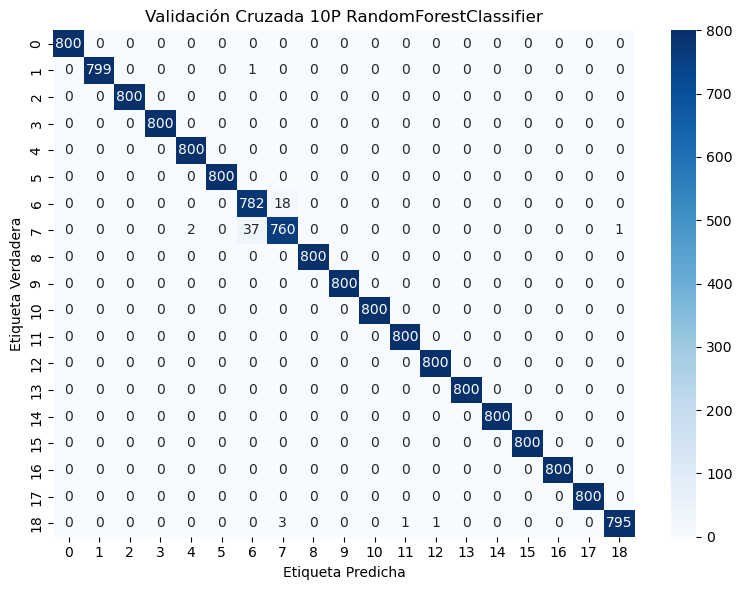

Puntuaciones (F1-macro):
  0.88503  0.93190  0.94380  0.97941  0.91462
  0.90402  0.93641  0.93194

Estadísticas de F1-macro:
Media:       0.92839
Mediana:     0.93192
Desvío:      0.02644
Mínimo:      0.88503
Máximo:      0.97941

Tiempos de entrenamiento (s):
  31.43838  30.81433  30.78233  32.06143  29.13621
  29.87326  28.45515  30.28029

Estadísticas de tiempos:
Media:       30.35517
Mediana:     30.53131
Desvío:      1.10746
Mínimo:      28.45515
Máximo:      32.06143


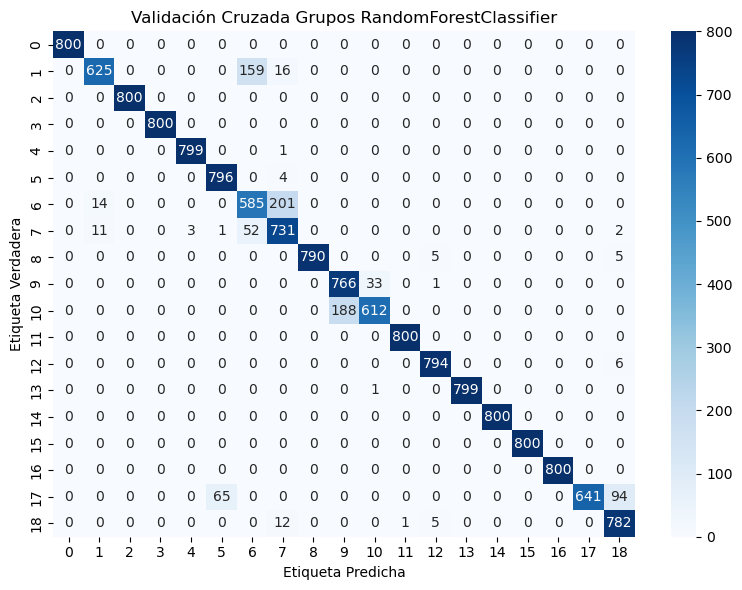

In [129]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
rf_loso = pipelinear_loso(
    model=rf,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


5 AdaBoost

Puntuaciones (F1-macro):
  0.76571  0.82563  0.86852  0.86643  0.83722
  0.89094  0.78180  0.81270

Estadísticas de F1-macro:
Media:       0.83112
Mediana:     0.83143
Desvío:      0.04084
Mínimo:      0.76571
Máximo:      0.89094

Tiempos de entrenamiento (s):
  400.41842  390.82461  394.59443  389.15064  398.27399
  400.05131  379.24187  404.90938

Estadísticas de tiempos:
Media:       394.68308
Mediana:     396.43421
Desvío:      7.60854
Mínimo:      379.24187
Máximo:      404.90938


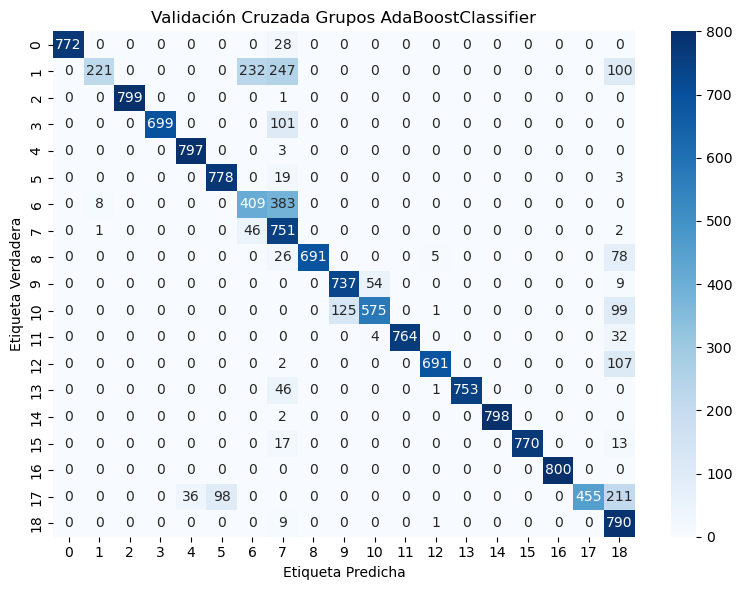

In [187]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# 1) Features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

base_estimator = DecisionTreeClassifier(max_depth=4)

model = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

# 4) Validación LOSO
n_splits = groups.nunique()

ada_loso = pipelinear_loso(
    model=model,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=n_splits
)


**6 Voting con diferentes Features**

In [ ]:
"""
 - Estandariza, selecciona características (SFS k=3) y ensambla (soft voting).
 - Evalúa con StratifiedKFold(10) y métricas macro: f1, accuracy, precision, recall.
"""

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 2) SequentialFeatureSelector (k=3, scoring interno f1_macro, cv=5) 
sfs1 = SequentialFeatureSelector(clf1, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs2 = SequentialFeatureSelector(clf2, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs3 = SequentialFeatureSelector(clf3, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('sfs', sfs1),
                    ('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('sfs', sfs2), ('rf', clf2)])
pipe_nb = Pipeline([('sfs', sfs3), ('nb', clf3)])

# 4) Ensamble de votación suave
eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

# 5) Función de evaluación renombrada
def evaluar_sfs_ensemble(model, X, y):
    """
    Estandariza, entrena el modelo y evalúa con CV estratificada.
    Métricas: f1_macro, accuracy, precision_macro, recall_macro + tiempos de entrenamiento
    """
    # Pipeline con scaler + model
    pipe = make_pipeline(StandardScaler(), model)

    # Diccionario de scorers macro 
    scoring = {
        'f1_macro':       make_scorer(f1_score,       average='macro'),
        'accuracy':       make_scorer(accuracy_score),
        'precision_macro':make_scorer(precision_score,average='macro'),
        'recall_macro':   make_scorer(recall_score,   average='macro'),
    }

    # CV externo: StratifiedKFold 10 folds, shuffle, semilla fija 
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # cross_validate con múltiples métricas y paralelo :contentReference[oaicite:6]{index=6}
    cv_results = cross_validate(estimator=pipe, X=X, y=y,
                                cv=cv, scoring=scoring,
                                return_train_score=False, n_jobs=-1)

    # Estadísticas resumen
    def stats_arr(arr):
        return {
            "Media":   np.mean(arr),
            "Mediana": np.median(arr),
            "Std":     np.std(arr),
            "Mínimo":  np.min(arr),
            "Máximo":  np.max(arr),
        }

    # Mostrar métricas por fold
    print("=== Métricas de test por fold ===")
    for metric in scoring:
        vals = cv_results[f'test_{metric}']
        stats = stats_arr(vals)
        print(f"\n> {metric}:")
        print("  " + "  ".join(f"{v:.4f}" for v in vals))
        for name, v in stats.items():
            print(f"    {name:<8}{v:.4f}")

    # Mostrar tiempos de entrenamiento
    times = cv_results["fit_time"]
    stats_t = stats_arr(times)
    print("\n=== Tiempos de entrenamiento (s) ===")
    print("  " + "  ".join(f"{t:.4f}" for t in times))
    for name, v in stats_t.items():
        print(f"    {name:<8}{v:.4f}")

    return cv_results

# 6) Para ejecutar con tus datos:
eclf_results = evaluar_sfs_ensemble(eclf, X, y)
eclf_results

# PCA

## 1. PCA con 10-fold CV

In [167]:
import os
import numpy as np
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_crossvalidation_pca(model, X, y):
    """
    Pipeline con estandarización + PCA (95% varianza explicada) + modelo.
    Imprime cuántas features había antes y cuántas retiene PCA, y luego
    evalúa usando validación cruzada estratificada 10-fold.
    """
    # 0) Codificación de etiquetas si vienen como texto
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_encoded = y
        etiquetas = np.unique(y)

    # ----------------------------------------------------
    # → NUEVO: calcular nº de features antes/después de PCA
    # ----------------------------------------------------
    scaler_temp = StandardScaler()
    X_scaled = scaler_temp.fit_transform(X)
    pca_temp = PCA(n_components=0.95)
    pca_temp.fit(X_scaled)
    n_before = X.shape[1]
    n_after  = pca_temp.n_components_
    print(f"Features originales: {n_before}")
    print(f"Features tras PCA (95% varianza): {n_after}\n")

    # 1) Scorers
    precision_macro_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_macro_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_macro_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy_scorer    = 'accuracy'

    # 2) Pipeline con PCA
    scaler = StandardScaler()
    pca    = PCA(n_components=0.95)
    pipe   = make_pipeline(scaler, pca, model)

    # 3) Validación cruzada
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_encoded,
        cv=cv,
        scoring={
            "f1_macro":        f1_macro_zd,
            "accuracy":        accuracy_scorer,
            "precision_macro": precision_macro_zd,
            "recall_macro":    recall_macro_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 4) Recoger métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(cv.get_n_splits())
    ]

    # 5) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 6) Impresión de resultados
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for etiqueta, valor in stats_scores.items():
        print(f"{etiqueta + ':':<12} {valor:.5f}")

    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for etiqueta, valor in stats_times.items():
        print(f"{etiqueta + ':':<12} {valor:.5f}")

    # 7) Matriz de confusión out-of-fold
    y_pred = cross_val_predict(pipe, X, y_encoded, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_encoded, y_pred)

    # 8) Guardar y mostrar la matriz
    output_folder = os.path.join("resultados_dsaa", "crossval_10k")
    os.makedirs(output_folder, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas, ax=ax)
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada 10 Folds {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    base_name = f"Validación Cruzada 10-Folds {model.__class__.__name__}"
    fig.savefig(os.path.join(output_folder, f"{base_name}_1080p.png"),
                dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base_name}_4k.png"),
                dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base_name}.svg"),
                bbox_inches='tight')

    return scores, times, all_scores


1 Naive Bayes PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.93881  0.95108  0.95356  0.95291  0.94216
  0.95577  0.95705  0.94092  0.95620  0.95528

Estadísticas de F1-macro:
Media:       0.95037
Mediana:     0.95323
Desvío:      0.00663
Mínimo:      0.93881
Máximo:      0.95705

Tiempos de entrenamiento (s):
  0.64706  0.62105  0.66606  0.62105  0.59805
  0.54904  0.62705  0.62105  0.39402  0.34202

Estadísticas de tiempos:
Media:       0.56865
Mediana:     0.62105
Desvío:      0.10507
Mínimo:      0.34202
Máximo:      0.66606


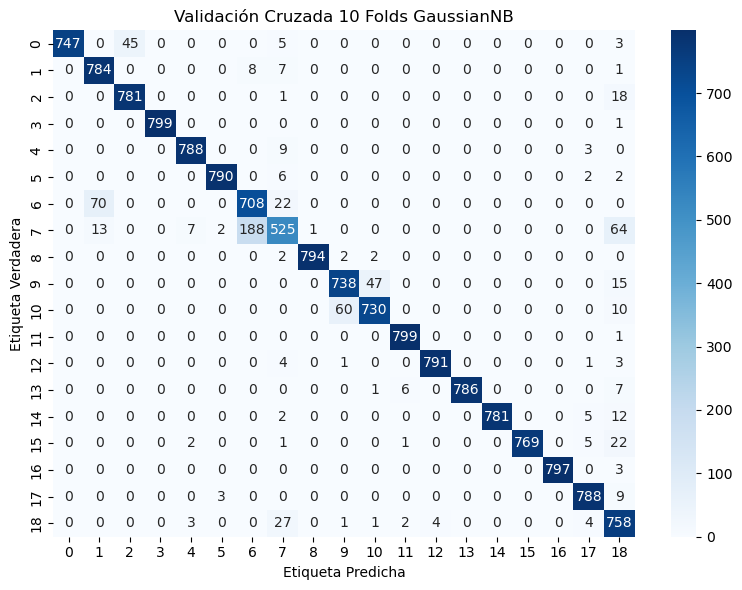

In [169]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results_pca = pipelinear_crossvalidation_pca(nb, X, y_encoded)

2 Logistic Regression PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.98791  0.99338  0.99211  0.98880  0.99081
  0.99146  0.99206  0.99079  0.99474  0.99073

Estadísticas de F1-macro:
Media:       0.99128
Mediana:     0.99114
Desvío:      0.00190
Mínimo:      0.98791
Máximo:      0.99474

Tiempos de entrenamiento (s):
  11.12785  9.16170  8.23063  12.18693  11.42787
  13.30601  7.55903  11.92190  9.30909  8.29902

Estadísticas de tiempos:
Media:       10.25300
Mediana:     10.21847
Desvío:      1.87721
Mínimo:      7.55903
Máximo:      13.30601


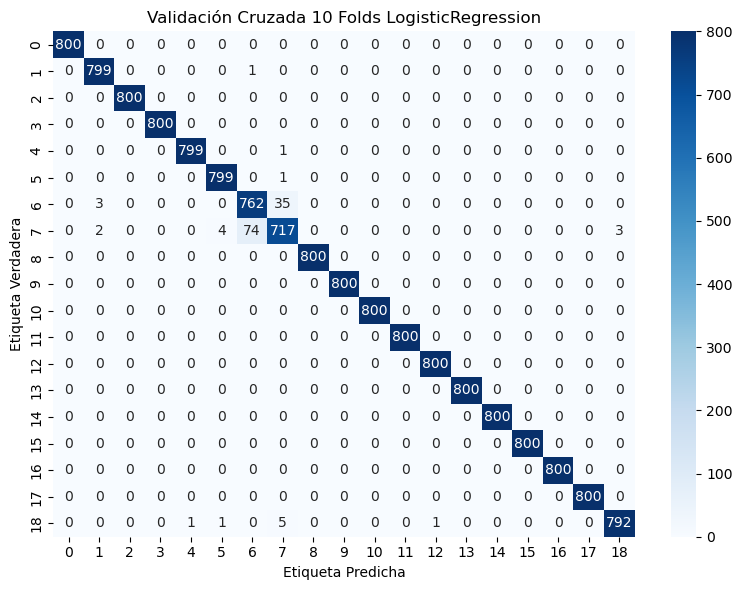

In [170]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results_pca = pipelinear_crossvalidation_pca(lr, X, y_encoded)

3 MLP PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.97844  0.96689  0.97643  0.98422  0.97760
  0.97943  0.97872  0.97863  0.98306  0.98465

Estadísticas de F1-macro:
Media:       0.97881
Mediana:     0.97867
Desvío:      0.00481
Mínimo:      0.96689
Máximo:      0.98465

Tiempos de entrenamiento (s):
  3.03309  2.97308  3.24164  3.07709  3.10802
  3.06709  2.75747  3.04056  1.76818  1.55916

Estadísticas de tiempos:
Media:       2.76254
Mediana:     3.03682
Desvío:      0.56323
Mínimo:      1.55916
Máximo:      3.24164


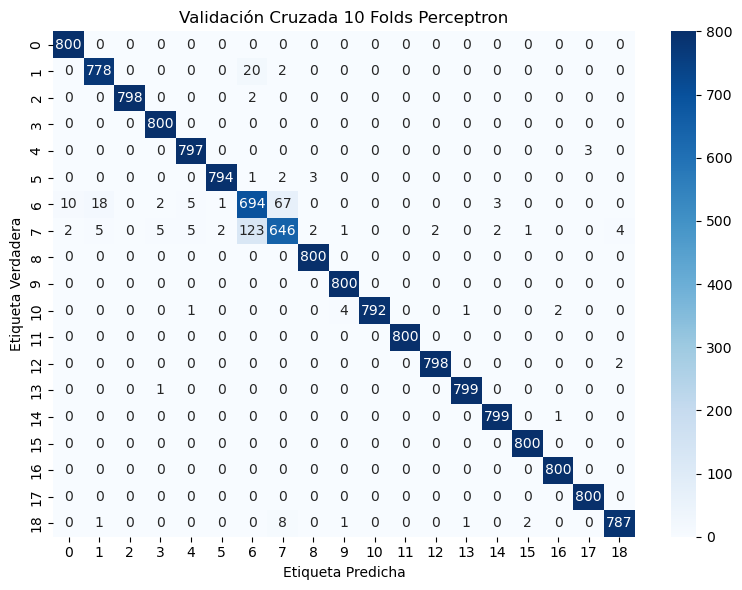

In [172]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results_pca = pipelinear_crossvalidation_pca(perceptron, X, y_encoded)

4 Random Forest PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.98439  0.98872  0.98940  0.98748  0.98491
  0.98745  0.98723  0.98130  0.98603  0.98470

Estadísticas de F1-macro:
Media:       0.98616
Mediana:     0.98663
Desvío:      0.00228
Mínimo:      0.98130
Máximo:      0.98940

Tiempos de entrenamiento (s):
  21.65265  21.88772  23.26036  23.48026  21.73049
  22.98525  23.43925  22.09834  17.02912  16.73456

Estadísticas de tiempos:
Media:       21.42980
Mediana:     21.99303
Desvío:      2.37109
Mínimo:      16.73456
Máximo:      23.48026


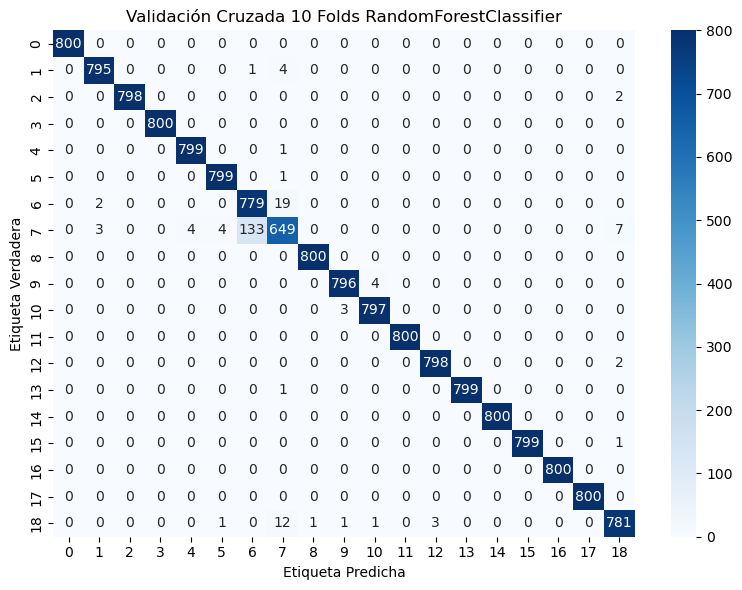

In [173]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results_pca = pipelinear_crossvalidation_pca(rf, X, y_encoded)

5 AdaBoost PCA

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.95951  0.96876  0.97326  0.96875  0.96145
  0.96280  0.96688  0.97249  0.95605  0.95231

Estadísticas de F1-macro:
Media:       0.96423
Mediana:     0.96484
Desvío:      0.00662
Mínimo:      0.95231
Máximo:      0.97326

Tiempos de entrenamiento (s):
  136.50936  138.38051  143.79992  144.01393  138.33850
  136.82439  141.79876  142.04979  110.88342  111.06445

Estadísticas de tiempos:
Media:       134.36630
Mediana:     138.35951
Desvío:      11.97204
Mínimo:      110.88342
Máximo:      144.01393


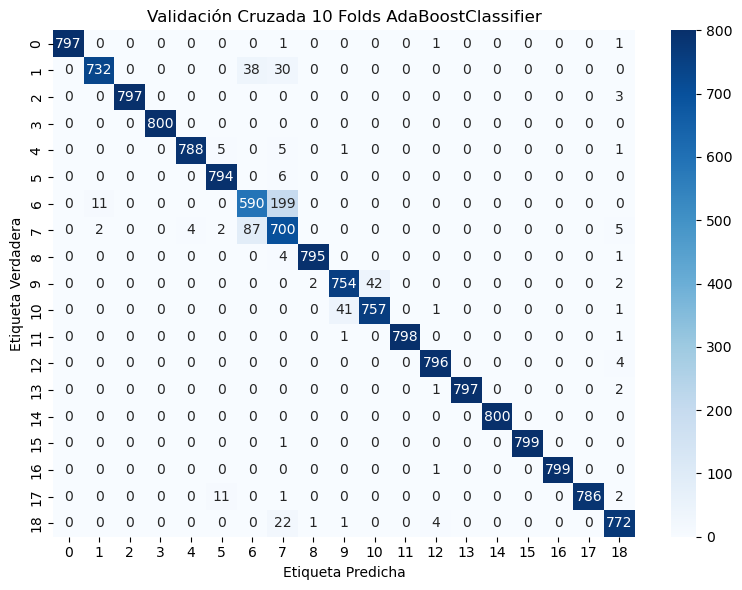

In [194]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada  = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

ada_results_pca = pipelinear_crossvalidation_pca(ada, X, y_encoded)

6 Voting PCA

## 2. PCA con Group Cross Validation

In [199]:
import os
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_validate, GroupKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Para que el texto sea seleccionable en SVG
matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_loso_pca(model, X, y, groups, n_splits=8):
    """
    Ajusta un pipeline (escalador + PCA al 95% de varianza + modelo)
    con CV por grupos (GroupKFold para leave-one-subject-out sobre 8 sujetos).
    X: features, y: etiquetas, groups: vector de grupos.
    Muestra estadísticas de F1-macro, accuracy, precision-macro y recall-macro
    (con zero_division=0), imprime todo en español, y dibuja/exporta la
    matriz de confusión out-of-fold en PNG (1080p, 4K) y SVG.
    El archivo se guarda en resultados_dsaa/crossval_groups_pca/
    con nombre "Validación Cruzada Grupos PCA {NombreDelClasificador}".
    """
    # 0) Codificación de etiquetas si vienen como texto
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_enc = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_enc = y
        etiquetas = np.unique(y)

    # ----------------------------------------------------
    # → Cálculo de componentes antes/después de PCA al 95% 
    # ----------------------------------------------------
    scaler_temp = StandardScaler()
    X_scaled = scaler_temp.fit_transform(X)
    pca_temp = PCA(n_components=0.95)
    pca_temp.fit(X_scaled)
    n_before = X.shape[1]
    n_after  = pca_temp.n_components_
    print(f"Features originales: {n_before}")
    print(f"Features tras PCA (95% varianza): {n_after}\n")

    # 1) Scorers
    precision_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy     = 'accuracy'

    # 2) Pipeline + PCA + GroupKFold
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=0.95),
        model
    )
    cv = GroupKFold(n_splits=n_splits)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_enc, groups=groups,
        cv=cv,
        scoring={
            "f1_macro":        f1_zd,
            "accuracy":        accuracy,
            "precision_macro": precision_zd,
            "recall_macro":    recall_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 3) Extraer métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(n_splits)
    ]

    # 4) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 5) Impresión de métricas (5 decimales)
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for k, v in stats_scores.items():
        print(f"{k + ':':<12} {v:.5f}")
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for k, v in stats_times.items():
        print(f"{k + ':':<12} {v:.5f}")

    # 6) Predicciones out-of-fold y matriz de confusión
    y_pred = cross_val_predict(
        pipe, X, y_enc,
        groups=groups,
        cv=cv,
        n_jobs=-1
    )
    cm = confusion_matrix(y_enc, y_pred)

    # 7) Carpeta de salida
    output_folder = os.path.join("resultados_dsaa", "crossval_groups_pca")
    os.makedirs(output_folder, exist_ok=True)

    # 8) Dibujar matriz de confusión en español
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=etiquetas, yticklabels=etiquetas, ax=ax
    )
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada Grupos PCA {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    # 9) Guardar en varios formatos
    base = f"Validación Cruzada Grupos PCA {model.__class__.__name__}"
    fig.savefig(os.path.join(output_folder, f"{base}_1080p.png"), dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}_4k.png"),   dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}.svg"),              bbox_inches='tight')

    return scores, times, all_scores

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.83807  0.83431  0.93284  0.82708  0.77221
  0.85295  0.93293  0.88176

Estadísticas de F1-macro:
Media:       0.85902
Mediana:     0.84551
Desvío:      0.05132
Mínimo:      0.77221
Máximo:      0.93293

Tiempos de entrenamiento (s):
  0.57805  0.65206  0.62705  0.63506  0.61905
  0.63906  0.49004  0.58504

Estadísticas de tiempos:
Media:       0.60318
Mediana:     0.62305
Desvío:      0.04909
Mínimo:      0.49004
Máximo:      0.65206


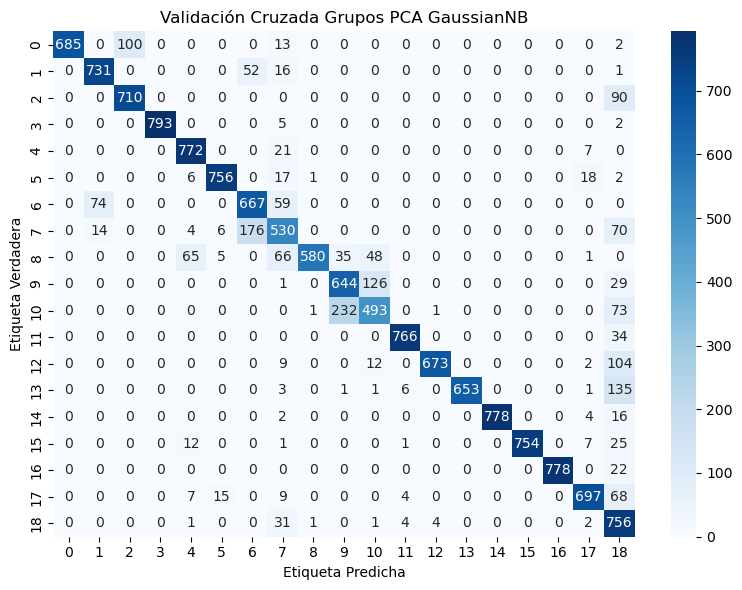

In [201]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
model = GaussianNB()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
nb_loso_pca = pipelinear_loso_pca(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.90854  0.93502  0.94555  0.93084  0.91075
  0.96497  0.91679  0.94511

Estadísticas de F1-macro:
Media:       0.93220
Mediana:     0.93293
Desvío:      0.01832
Mínimo:      0.90854
Máximo:      0.96497

Tiempos de entrenamiento (s):
  8.27863  7.56458  7.24655  8.80467  7.93161
  11.68789  7.21655  8.63566

Estadísticas de tiempos:
Media:       8.42077
Mediana:     8.10512
Desvío:      1.35504
Mínimo:      7.21655
Máximo:      11.68789


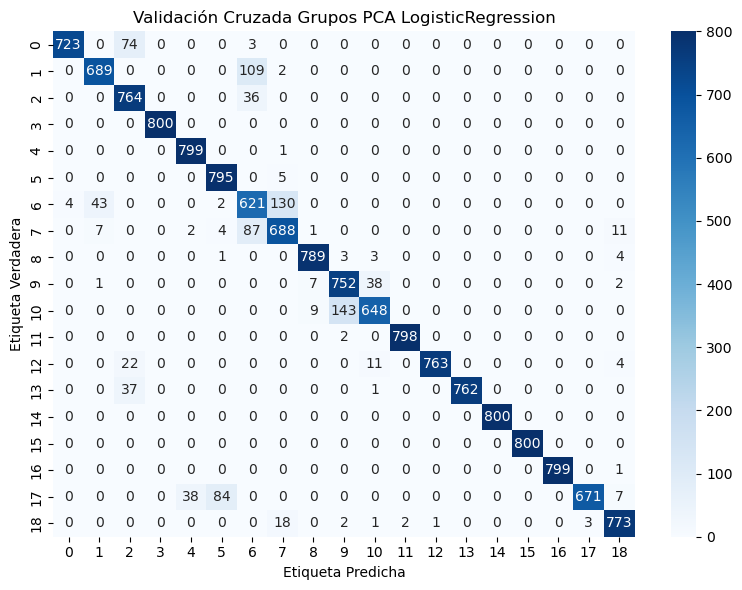

In [203]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
lr_loso_pca = pipelinear_loso_pca(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.84593  0.90137  0.89776  0.89837  0.78432
  0.88530  0.94227  0.85477

Estadísticas de F1-macro:
Media:       0.87626
Mediana:     0.89153
Desvío:      0.04452
Mínimo:      0.78432
Máximo:      0.94227

Tiempos de entrenamiento (s):
  2.51719  2.78521  2.84621  2.80321  2.71020
  2.76422  2.66620  2.55320

Estadísticas de tiempos:
Media:       2.70571
Mediana:     2.73721
Desvío:      0.11145
Mínimo:      2.51719
Máximo:      2.84621


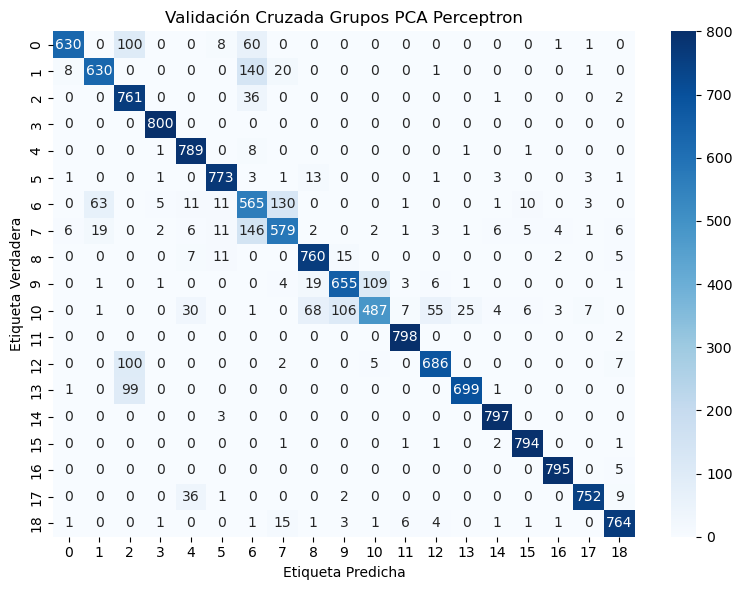

In [205]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
from sklearn.linear_model import Perceptron
model = Perceptron()

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
mlp_loso_pca = pipelinear_loso_pca(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


Puntuaciones (F1-macro):
  0.99469  0.99605  0.99540  0.99671  0.99277
  0.99539  0.99934  0.99538  0.99477  0.99803

Estadísticas de F1-macro:
Media:       0.99585
Mediana:     0.99540
Desvío:      0.00174
Mínimo:      0.99277
Máximo:      0.99934

Tiempos de entrenamiento (s):
  30.53632  31.78041  29.92427  30.51832  31.50339
  31.69940  31.39938  30.47231  22.77973  22.33469

Estadísticas de tiempos:
Media:       29.29482
Mediana:     30.52732
Desvío:      3.42020
Mínimo:      22.33469
Máximo:      31.78041


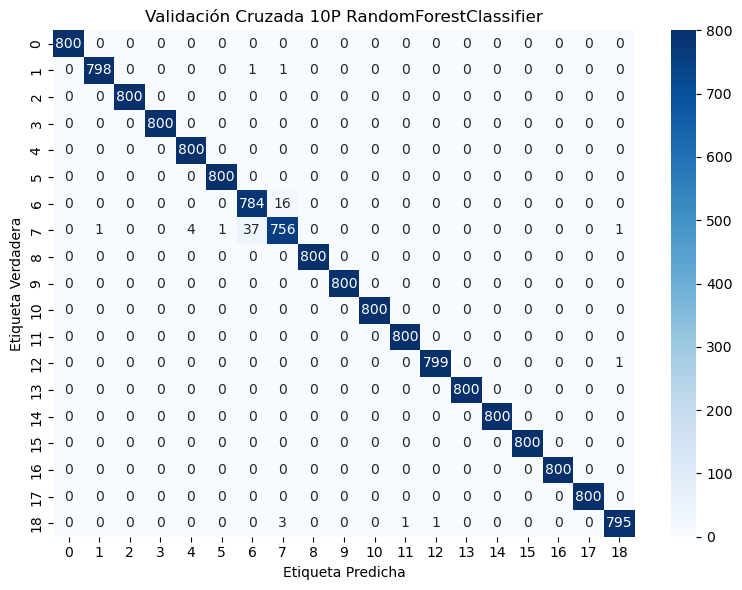

Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.82996  0.93907  0.92095  0.82868  0.93260
  0.90308  0.94527  0.87682

Estadísticas de F1-macro:
Media:       0.89705
Mediana:     0.91201
Desvío:      0.04408
Mínimo:      0.82868
Máximo:      0.94527

Tiempos de entrenamiento (s):
  24.53592  24.42813  25.19901  23.74010  23.91570
  24.02448  23.07588  22.80836

Estadísticas de tiempos:
Media:       23.96595
Mediana:     23.97009
Desvío:      0.72871
Mínimo:      22.80836
Máximo:      25.19901


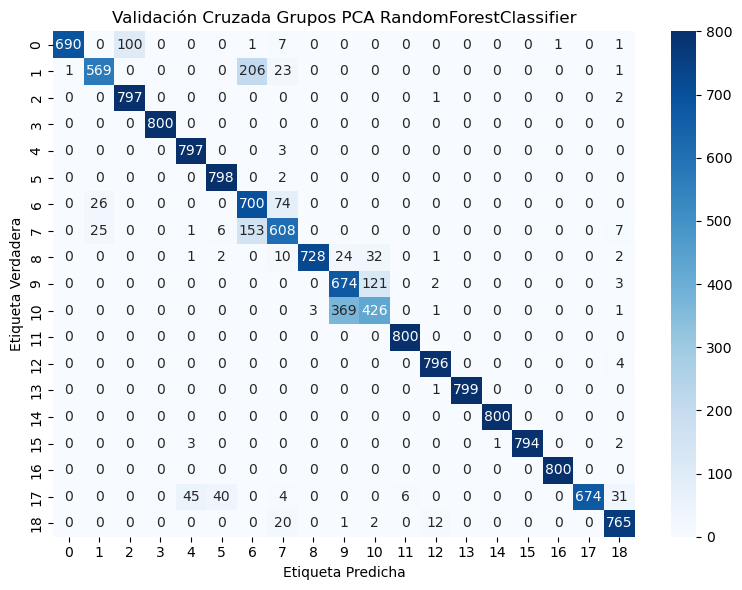

In [207]:
from sklearn.preprocessing import LabelEncoder

# 1) Separar features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

# 4) Número de pliegues = número de grupos únicos
n_splits = examples["person_id"].nunique()

# 5) Llamada a la función
rf_loso_pca = pipelinear_loso_pca(
    model=rf,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)


Features originales: 240
Features tras PCA (95% varianza): 85

Puntuaciones (F1-macro):
  0.80226  0.93935  0.87054  0.80683  0.86738
  0.76830  0.89952  0.72756

Estadísticas de F1-macro:
Media:       0.83522
Mediana:     0.83710
Desvío:      0.06635
Mínimo:      0.72756
Máximo:      0.93935

Tiempos de entrenamiento (s):
  134.89461  136.89603  141.15238  141.22189  136.19283
  141.89992  140.12347  139.07690

Estadísticas de tiempos:
Media:       138.93225
Mediana:     139.60018
Desvío:      2.45895
Mínimo:      134.89461
Máximo:      141.89992


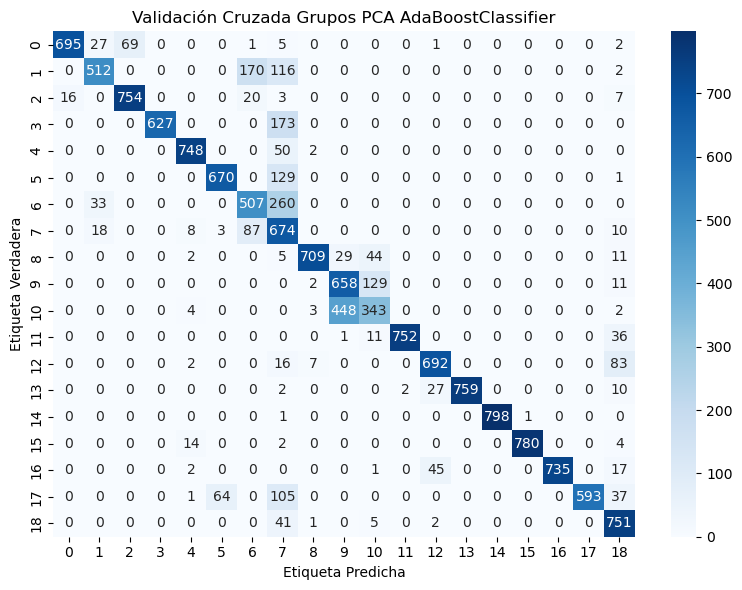

In [208]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# 1) Features, target y grupos
X      = examples.drop(columns=["activity", "person_id"])
y      = examples["activity"]
groups = examples["person_id"]

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

base_estimator = DecisionTreeClassifier(max_depth=4)

model = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

# 4) Validación LOSO
n_splits = groups.nunique()

ada_loso_pca = pipelinear_loso_pca(
    model=model,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=n_splits
)


# PCA Kernel

## 1 PCA Kernel 10-fold CV

In [216]:
import os
import numpy as np
from sklearn.decomposition import KernelPCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_crossvalidation_kernel_pca(
    model, X, y,
    kernel='rbf',
    n_components=0.95,
    **kpca_kwargs
):
    """
    Pipeline con estandarización + KernelPCA + modelo.
    - kernel: tipo de kernel para KernelPCA ('rbf', 'poly', 'sigmoid', ...)
    - n_components: float entre 0 y 1 para varianza explicada, o int num de comps.
    - kpca_kwargs: argumentos extra (gamma, degree, coef0, etc.)
    
    Realiza validación cruzada estratificada 10-fold y reporta:
      • F1-macro, accuracy, precision-macro, recall-macro
      • Estadísticos (media, mediana, desviación, min, max)
      • Matriz de confusión out-of-fold (PNG 1080p, 4K y SVG)
    """
    # 0) Codificar etiquetas si es necesario
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_enc = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_enc = y
        etiquetas = np.unique(y)

    # 1) Scorers
    precision_macro_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_macro_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_macro_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy_scorer    = 'accuracy'

    # 2) KernelPCA dentro del pipeline
    scaler = StandardScaler()
    kpca   = KernelPCA(n_components=n_components,
                       kernel=kernel,
                       fit_inverse_transform=False,
                       **kpca_kwargs)
    pipe = make_pipeline(scaler, kpca, model)

    # 3) CV estratificada
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_enc,
        cv=cv,
        scoring={
            "f1_macro":        f1_macro_zd,
            "accuracy":        accuracy_scorer,
            "precision_macro": precision_macro_zd,
            "recall_macro":    recall_macro_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 4) Recoger métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(cv.get_n_splits())
    ]

    # 5) Estadísticos
    def stats_arr(a):
        return {
            "Media":   np.mean(a),
            "Mediana": np.median(a),
            "Desvío":  np.std(a),
            "Mínimo":  np.min(a),
            "Máximo":  np.max(a),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 6) Impresión
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for k, v in stats_scores.items():
        print(f"{k+':':<12} {v:.5f}")

    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for k, v in stats_times.items():
        print(f"{k+':':<12} {v:.5f}")

    # 7) Matriz de confusión out-of-fold
    y_pred = cross_val_predict(pipe, X, y_enc, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_enc, y_pred)

    # 8) Guardar y mostrar
    out = os.path.join("resultados_dsaa", "crossval_kernelpca")
    os.makedirs(out, exist_ok=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas, ax=ax)
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'CV 10-Folds KernelPCA({kernel}) + {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    base = f"CV-KernelPCA-{kernel}-{model.__class__.__name__}"
    fig.savefig(os.path.join(out, f"{base}_1080p.png"), dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(out, f"{base}_4k.png"), dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(out, f"{base}.svg"),       bbox_inches='tight')

    return scores, times, all_scores

In [ ]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results_pca_kernel = pipelinear_crossvalidation_kernel_pca(nb, X, y_encoded)

## 2 PCA Kernel 8-Group Cross Validation